In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
data_path = os.path.join("../results/modelV1.dim1.0.folds10_id20251116143504/iet0.ieta0.pkl")
data = pd.read_pickle(data_path)
data.columns

Index(['file_path', 'fold', 'best_sp_value', 'best_fa_value', 'best_pd_value',
       'best_weights', 'history'],
      dtype='object')

In [3]:
from typing import Any

def create_dict_results() -> dict[str, Any]:
    return {"fold": -1,
        "best_sp": -1,
        "pd": -1,
        "fa": -1,
        "auc_score": -1,
        'train_loss': None, 
        'train_acc': None,
        'val_loss': None, 
        'val_acc': None}

In [5]:
# def get_best_results():
best_fold_index = -1
best_sp_value = -1
results = create_dict_results()
for index, data_history in enumerate(data["history"]):
    fold_callbackMetrics = data_history["callbackMetrics"]
    # for callback in fold_callbackMetrics:
    best_sp = fold_callbackMetrics["max_sp_val"]
    max_index = np.argmax(fold_callbackMetrics["max_sp_val"])

    if best_sp[max_index] > best_sp_value:
        best_fold_index = max_index
        best_sp_value = best_sp[max_index] 
        results["fold"] = data.iloc[index]["fold"]
        results["best_sp"] = best_sp[max_index]

        results['train_loss'] = (data_history["train_loss"])
        results['train_acc'] = (data_history["train_acc"])
        results['val_loss'] = (data_history["val_loss"])
        results['val_acc'] = (data_history["val_acc"])


In [6]:
from typing import Union
def plot_model_metrics(best_model_details: dict[str, Union[str, int, object]]) -> None:
    if best_model_details is None:
        print("Erro: Detalhes do melhor modelo não encontrados. Por favor, execute 'get_best_sp_model' primeiro.")
    else:
        # --- 1. Extrair os Dados do Histórico ---
        history_data = best_model_details
    
        epochs = range(1, len(history_data['train_loss']) + 1)
    
        # Métricas comuns
        train_loss = history_data['train_loss']
        val_loss = history_data['val_loss']
        train_accuracy = history_data['train_acc']
        val_accuracy = history_data['val_acc']
    
        # Valores de SP, FPR e TPR do callback SP
        callbackMetrics = history_data["callbackMetrics"]
        val_sp = callbackMetrics.get('max_sp_val') # .get() para evitar KeyError se a chave não existir
        val_fa = callbackMetrics.get('max_sp_fa_val') # FPR
        val_pd = callbackMetrics.get('max_sp_pd_val') # TPR

        # Verifica se as métricas do SP estão presentes
        if val_sp is None or val_fa is None or val_pd is None:
            print("Aviso: Algumas métricas (SP, FPR, TPR) não encontradas no histórico. Verifique a implementação do seu callback 'sp'.")
            # Podemos definir como arrays vazios ou None para que os plots condicionais funcionem
            val_sp, val_fa, val_pd = None, None, None
    
        # --- 2. Plotar as Curvas de Aprendizagem (Loss, Accuracy, e SP/FPR/TPR) ---
        plt.figure(figsize=(18, 6), clear=True, num=1) # Aumenta a figura para 3 subplots
    
        # Plot Loss
        plt.subplot(1, 3, 1) # 1 linha, 3 colunas, 1º plot
        plt.plot(epochs, train_loss, 'o-', label='Perda no Treinamento')
        plt.plot(epochs, val_loss, 'o-', label='Perda na Validação')
        plt.title('Curvas de Perda (Loss)')
        plt.xlabel('Época')
        plt.ylabel('Perda')
        plt.grid(True)
        plt.legend()
    
        # Plot Accuracy
        plt.subplot(1, 3, 2) # 1 linha, 3 colunas, 2º plot
        plt.plot(epochs, train_accuracy, 'o-', label='Acurácia no Treinamento')
        plt.plot(epochs, val_accuracy, 'o-', label='Acurácia na Validação')
        plt.title('Curvas de Acurácia')
        plt.xlabel('Época')
        plt.ylabel('Acurácia')
        plt.grid(True)
        plt.legend()
    
        # Plot SP, TPR e FPR (se disponíveis)
        plt.subplot(1, 3, 3) # 1 linha, 3 colunas, 3º plot
        if val_sp is not None:
            plt.plot(epochs, val_sp, 'o-', label='Índice SP', color='purple')
        if val_pd is not None:
            plt.plot(epochs, val_pd, 'o-', label='TPR (Verdadeiros Positivos)', color='darkgreen')
        if val_fa is not None:
            plt.plot(epochs, val_fa, 'o-', label='FPR (Falsos Positivos)', color='darkred')
    
        if val_sp is not None:
            # Linha vertical para o melhor SP
            best_sp_epoch_idx = np.argmax(val_sp)
            plt.axvline(x=epochs[best_sp_epoch_idx], color='blue', linestyle='--', label=f'Melhor SP (Época {epochs[best_sp_epoch_idx]})')
    
        plt.title('Métricas de Desempenho (SP, TPR, FPR)')
        plt.xlabel('Época')
        plt.ylabel('Valor da Métrica')
        plt.grid(True)
        plt.legend()
    
        plt.tight_layout()
        # model_metrics_file_template = "iet{iet}.ieta{ieta}_modelMetrics.pdf".format(
        #     ieta = ieta, 
        #     iet=iet)
        # plt.savefig(os.path.join(folder_path, model_metrics_file_template))
        plt.show()
        # plt.close()
    
        # print("\nCurvas de aprendizagem (Loss, Accuracy, SP, TPR, FPR) geradas com sucesso para o melhor modelo SP!")


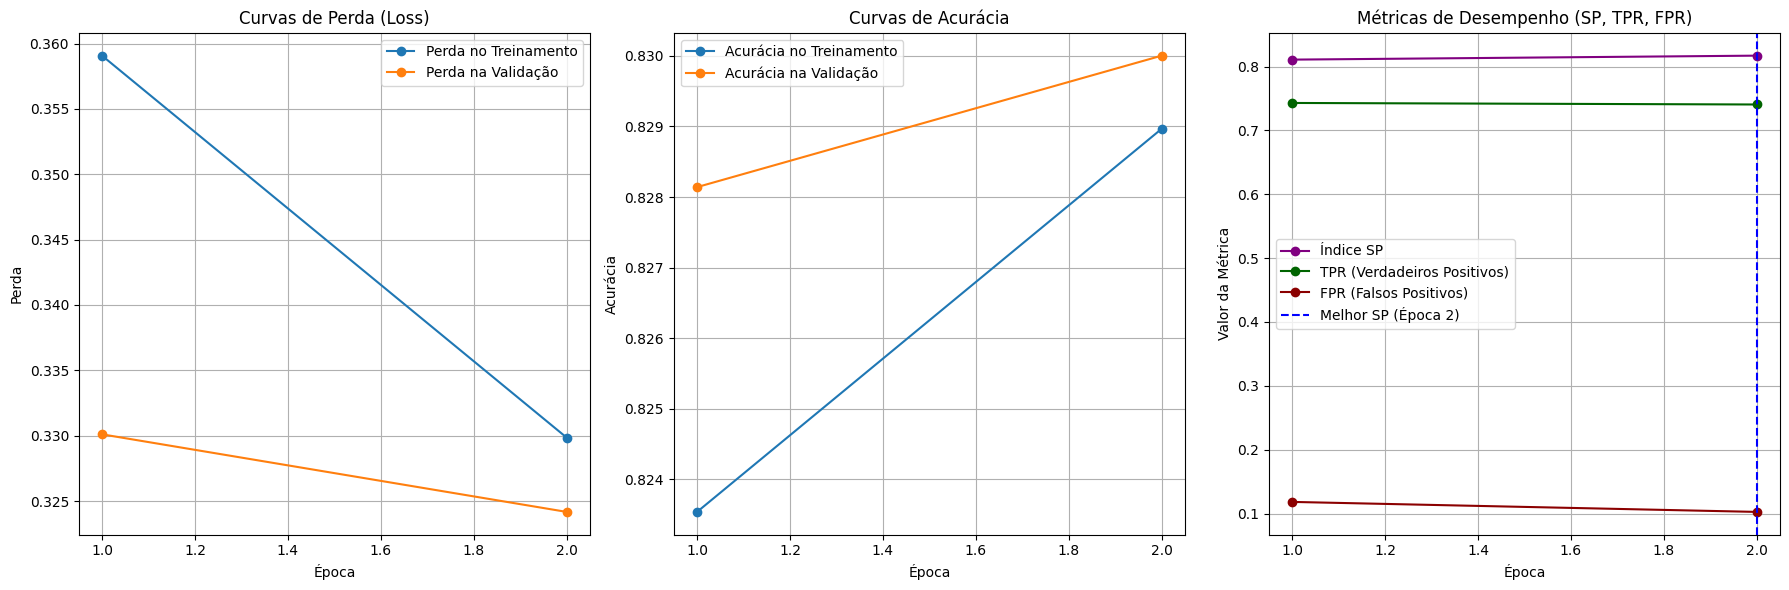

In [7]:
plot_model_metrics(data["history"][2])

In [10]:
def plot_model_acc(best_model_details,
                   folder_path=None,iet=0, ieta=0) -> float:
        print("Gerando Curva ROC...")
        tpr, fpr  = best_model_details["pd"], best_model_details["fa"]
        auc_score = best_model_details["auc_score"]
    
        plt.figure(figsize=(8, 6), clear=True, num=1)
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Taxa de Falsos Positivos (FPR)')
        plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
        plt.title('Curva ROC do Modelo'+ \
             f"\n({iet},{ieta})")
        plt.legend(loc="lower right")
        plt.grid(True)
        # roc_file_template = "ns{ns}.iet{iet}.ieta{ieta}_ROC.pdf".format(
        #     ns = ns,
        #     ieta = ieta, 
        #     iet=iet)
        # plt.savefig(os.path.join(folder_path, roc_file_template))
        plt.show()
        # plt.close()
        # --- 4. Histograma de Saída da Rede (Sinal vs. Background) ---
        print("Gerando Histograma de Saída da Rede...")
    
        # # Separar as previsões para sinal e background
        # # Assumindo que 1 é sinal e 0 é background em y_test_final
        # predictions_signal = y_pred_proba[y_test_final == 1]
        # predictions_background = y_pred_proba[y_test_final == 0]
    
        # plt.figure(figsize=(10, 6), clear=True, num=1)
        # plt.hist(predictions_background, bins=50, alpha=0.7, label='Background', color='red', density=True)
        # plt.hist(predictions_signal, bins=50, alpha=0.7, label='Sinal', color='green', density=True)
        # plt.xlabel('Saída da Rede (Probabilidade)')
        # plt.ylabel('Densidade')
        # plt.yscale('log')
        # plt.title('Histograma de Saída da Rede para Sinal e Background'+ \
        #      f"\n({iet},{ieta})")
        # plt.legend(loc='upper right')
        # plt.grid(True)
        # model_output_file_template = "ns{ns}.iet{iet}.ieta{ieta}_modelOutput.pdf".format(
        #     ns = ns,
        #     ieta = ieta, 
        #     iet=iet)
        # plt.savefig(os.path.join(folder_path, model_output_file_template))
        # # plt.show()
        # # plt.close()
    
        print("\nVisualizações geradas com sucesso!")
        return auc_score

Gerando Curva ROC...


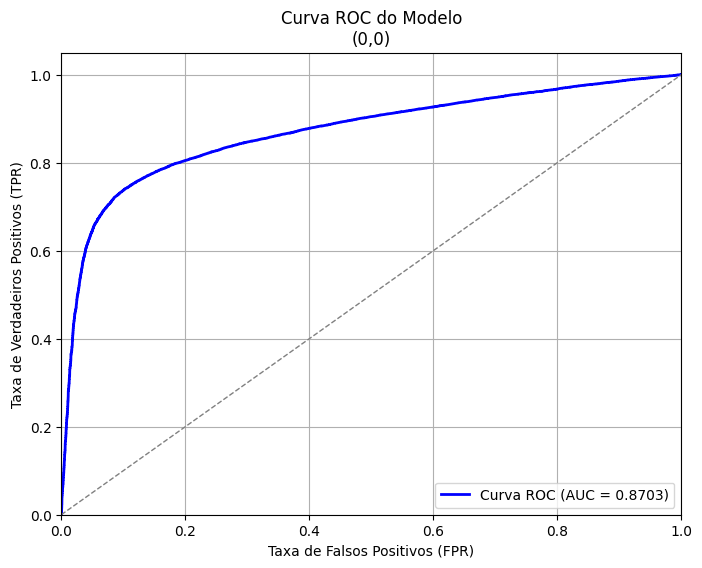

Gerando Histograma de Saída da Rede...

Visualizações geradas com sucesso!


np.float64(0.8703409820818245)

In [12]:
plot_model_acc(data["history"][2]["callbackMetrics"])